In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project root = parent of notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TRAIN_FILE = ROOT / "data" / "train.tags"
PRED_FILE = ROOT / "results" / "dev.out"
GOLD_FILE = ROOT / "data" / "dev.tags"

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Figures directory:", FIGURES_DIR)

Project root: d:\PA-1-NLP
Figures directory: d:\PA-1-NLP\figures


In [2]:
def split_word_tag(token: str) -> tuple[str, str]:
    return token.rsplit("/", 1)


def read_tagged_file(path: Path):
    sentences = []

    for line_number, line in enumerate(
        path.read_text(encoding="utf-8").splitlines(), 1
    ):
        sentence = []

        for token in line.split():
            if "/" not in token:
                raise ValueError(
                    f"Malformed token on line {line_number}: {token!r}"
                )
            sentence.append(split_word_tag(token))

        if sentence:
            sentences.append(sentence)

    return sentences


train = read_tagged_file(TRAIN_FILE)
predictions = read_tagged_file(PRED_FILE)
gold = read_tagged_file(GOLD_FILE)

print(f"Training sentences: {len(train)}")
print(f"Prediction sentences: {len(predictions)}")
print(f"Gold sentences: {len(gold)}")

Training sentences: 39832
Prediction sentences: 1993
Gold sentences: 1993


In [3]:
train_vocabulary = {
    word
    for sentence in train
    for word, _ in sentence
}

rows = []

for sentence_idx, (pred_sentence, gold_sentence) in enumerate(
    zip(predictions, gold)
):
    if len(pred_sentence) != len(gold_sentence):
        raise ValueError(
            f"Sentence {sentence_idx + 1} has different lengths."
        )

    for (pred_word, pred_tag), (gold_word, gold_tag) in zip(
        pred_sentence, gold_sentence
    ):
        if pred_word != gold_word:
            raise ValueError(
                f"Word mismatch: {pred_word!r} vs {gold_word!r}"
            )

        rows.append(
            {
                "word": gold_word,
                "gold": gold_tag,
                "predicted": pred_tag,
                "known": gold_word in train_vocabulary,
                "correct": gold_tag == pred_tag,
            }
        )

df = pd.DataFrame(rows)

print(df.head())
print(f"\nTotal tokens: {len(df):,}")

    word gold predicted  known  correct
0    For   IN        IN   True     True
1    six   CD        CD   True     True
2  years  NNS       NNS   True     True
3      ,    ,         ,   True     True
4     T.  NNP       NNP   True     True

Total tokens: 47,633


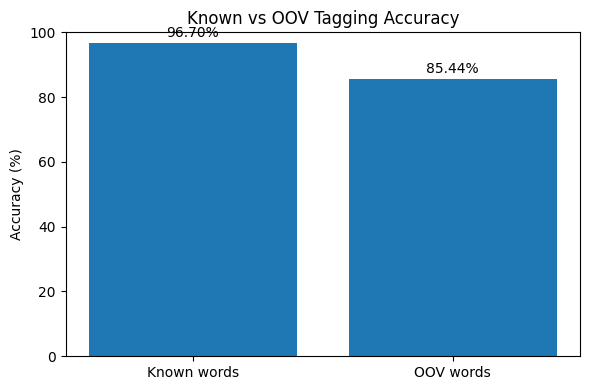

In [4]:
known_accuracy = df.loc[df["known"], "correct"].mean() * 100
oov_accuracy = df.loc[~df["known"], "correct"].mean() * 100

accuracy_df = pd.DataFrame(
    {
        "Category": ["Known words", "OOV words"],
        "Accuracy": [known_accuracy, oov_accuracy],
    }
)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    accuracy_df["Category"],
    accuracy_df["Accuracy"],
)

ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("Known vs OOV Tagging Accuracy")

for bar, value in zip(bars, accuracy_df["Accuracy"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "known_vs_oov_accuracy.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIGURES_DIR / "known_vs_oov_accuracy.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [8]:
tags = sorted(set(df["gold"]) | set(df["predicted"]))

confusion = pd.crosstab(
    pd.Categorical(df["gold"], categories=tags),
    pd.Categorical(df["predicted"], categories=tags),
).fillna(0).astype(int)

# Remove correct classifications from the error matrix.
error_matrix = confusion.copy()

for tag in tags:
    error_matrix.loc[tag, tag] = 0

# Keep only tags that participate in at least one error,
# either as a gold tag or as a predicted tag.
active_tags = error_matrix.index[
    (error_matrix.sum(axis=1) > 0) |
    (error_matrix.sum(axis=0) > 0)
]
active_tags = [tag for tag in active_tags if tag != "LS"]
error_matrix = error_matrix.loc[active_tags, active_tags]

print(f"Total tags: {len(tags)}")
print(f"Tags involved in misclassification: {len(active_tags)}")

error_matrix

Total tags: 44
Tags involved in misclassification: 30


col_0,.,CC,CD,DT,FW,IN,JJ,JJR,JJS,MD,...,RBS,RP,VB,VBD,VBG,VBN,VBP,VBZ,WDT,WP
row_0,,,,,,,,,,,,,,,,,,,,,
.,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CC,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CD,0,0,0,0,0,0,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DT,0,5,0,0,0,5,0,0,0,0,...,0,0,0,0,0,0,0,0,11,0
FW,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
IN,0,0,0,32,0,0,5,0,0,0,...,0,45,0,0,0,0,1,0,3,0
JJ,0,0,0,1,0,0,0,1,0,0,...,0,1,4,4,3,9,2,0,0,0
JJR,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
JJS,0,0,0,0,0,0,0,0,0,0,...,3,0,0,0,0,0,0,0,0,0


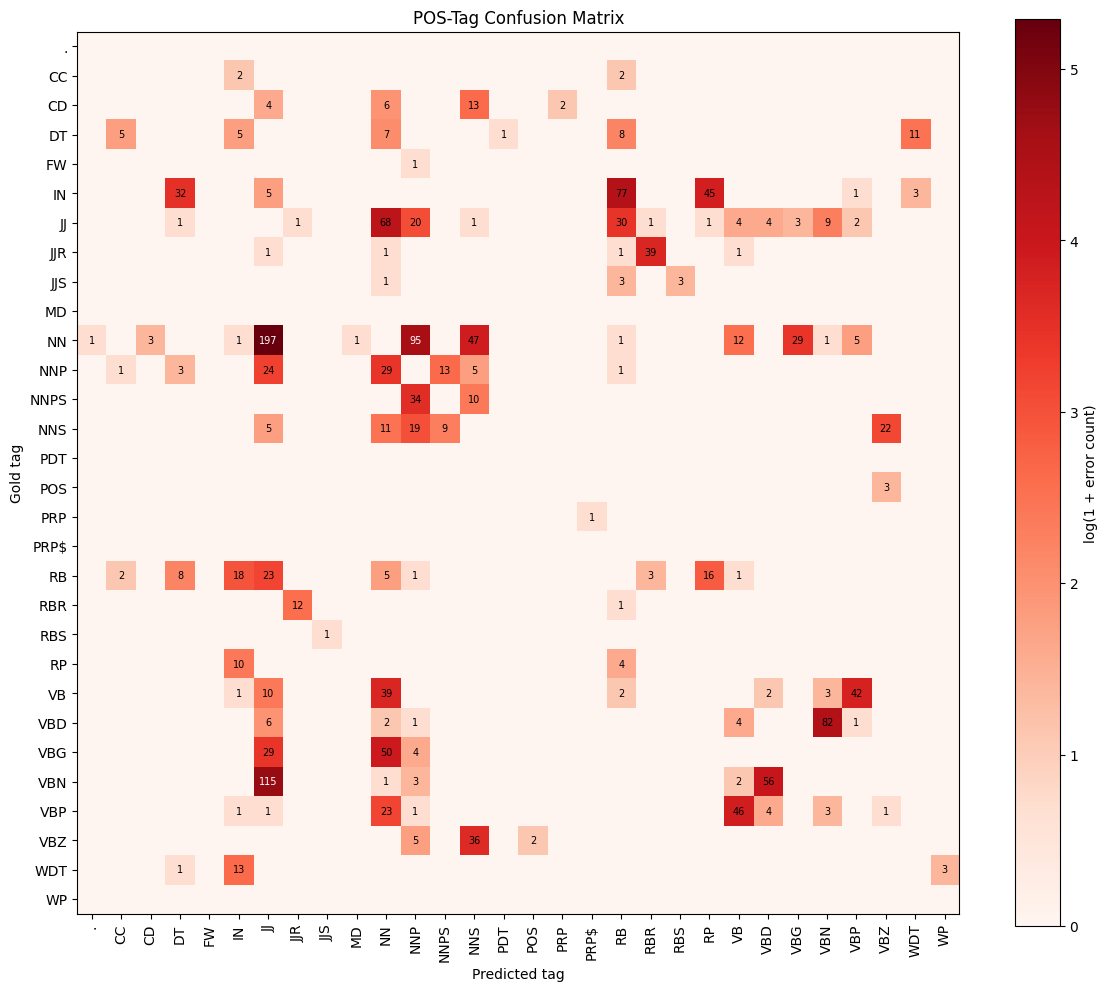

In [11]:
tags = list(error_matrix.index)
fig, ax = plt.subplots(
    figsize=(12, 10)
)

# Log scale improves visibility of smaller errors.
display_matrix = np.log1p(error_matrix.values)

image = ax.imshow(
    display_matrix,
    cmap="Reds",
    interpolation="nearest",
)

ax.set_xticks(np.arange(len(tags)))
ax.set_yticks(np.arange(len(tags)))

ax.set_xticklabels(tags)
ax.set_yticklabels(tags)

ax.set_xlabel("Predicted tag")
ax.set_ylabel("Gold tag")
ax.set_title("POS-Tag Confusion Matrix")

plt.setp(
    ax.get_xticklabels(),
    rotation=90,
)

# Add counts.
max_error = error_matrix.values.max()

for i in range(len(tags)):
    for j in range(len(tags)):
        value = error_matrix.iloc[i, j]

        if value == 0:
            continue

        text_color = (
            "white"
            if max_error > 0 and value > max_error * 0.45
            else "black"
        )

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=7,
            color=text_color,
        )

cbar = fig.colorbar(image, ax=ax)
cbar.set_label("log(1 + error count)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "confusion_matrix.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIGURES_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [12]:
error_df = df.loc[~df["correct"]].copy()

major_pairs = (
    error_df
    .groupby(["gold", "predicted"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

breakdown_rows = []

for gold_tag, predicted_tag in major_pairs:
    subset = error_df[
        (error_df["gold"] == gold_tag)
        & (error_df["predicted"] == predicted_tag)
    ]

    known = subset["known"].sum()
    oov = (~subset["known"]).sum()

    breakdown_rows.append(
        {
            "Confusion": f"{gold_tag} → {predicted_tag}",
            "Known": known,
            "OOV": oov,
        }
    )

breakdown_df = pd.DataFrame(breakdown_rows)

breakdown_df

,Confusion,Known,OOV
0,NN → JJ,162,35
1,VBN → JJ,113,2
2,NN → NNP,75,20
3,VBD → VBN,82,0
4,IN → RB,77,0
5,JJ → NN,47,21
6,VBN → VBD,55,1
7,VBG → NN,46,4
8,NN → NNS,46,1
9,VBP → VB,46,0


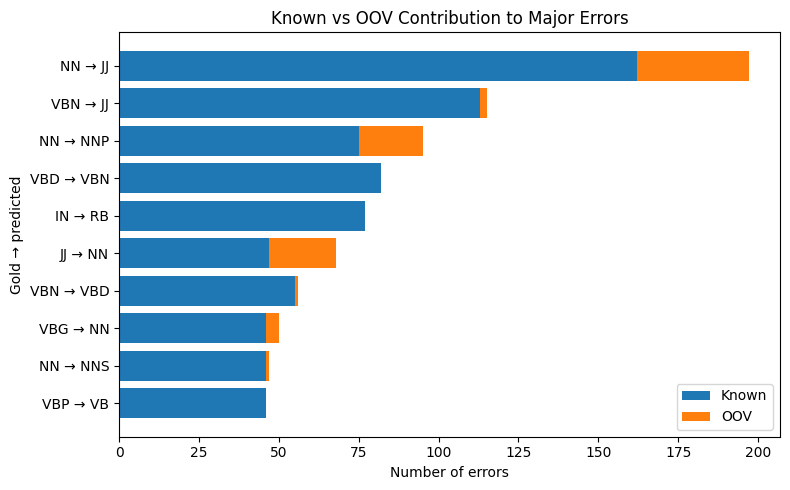

In [13]:
plot_df = breakdown_df.iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_df["Confusion"],
    plot_df["Known"],
    label="Known",
)

ax.barh(
    plot_df["Confusion"],
    plot_df["OOV"],
    left=plot_df["Known"],
    label="OOV",
)

ax.set_xlabel("Number of errors")
ax.set_ylabel("Gold → predicted")
ax.set_title("Known vs OOV Contribution to Major Errors")

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "known_oov_confusions.pdf",
    bbox_inches="tight",
)
plt.savefig(
    FIGURES_DIR / "known_oov_confusions.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()